# Imports and basic libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
import os

# Add project root to path so we can import src/
sys.path.append(os.path.abspath('..'))
from src.evaluate import sortino_ratio, sharpe_ratio, max_drawdown, total_return, cumulative_returns, spy_baseline

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# Load data
df = pd.read_csv('../data/processed/iv_features.csv')
df['date'] = pd.to_datetime(df['date'])

train = df[df['date'] <= '2023-12-31'].copy()
test  = df[df['date'] >= '2024-01-01'].copy()

print(f'Full dataset : {len(df):,} trading days')
print(f'Train (2020-2023): {len(train):,} days')
print(f'Test  (2024)     : {len(test):,} days')
print(f'Columns: {list(df.columns)}')
df.head()

Full dataset : 1,238 trading days
Train (2020-2023): 987 days
Test  (2024)     : 251 days
Columns: ['date', 'iv_xlk', 'iv_xlf', 'iv_xlv', 'zscore_xlk', 'zscore_xlf', 'zscore_xlv', 'realvol_xlk', 'realvol_xlf', 'realvol_xlv', 'ret_spy', 'ret_xlf', 'ret_xlk', 'ret_xlv', 'rf_daily']


,date,iv_xlk,iv_xlf,iv_xlv,zscore_xlk,zscore_xlf,zscore_xlv,realvol_xlk,realvol_xlf,realvol_xlv,ret_spy,ret_xlf,ret_xlk,ret_xlv,rf_daily
0,2020-01-30,0.149889,0.209032,0.117885,-0.179502,2.210717,-0.030615,0.155905,0.131356,0.104437,0.003240,0.012496,0.008607,-0.007288,0.000061
1,2020-01-31,0.245973,0.205686,0.153879,2.886153,1.852262,1.662989,0.186148,0.146792,0.123318,-0.018325,-0.021137,-0.027827,-0.020170,0.000060
2,2020-02-03,0.202139,0.192526,0.148319,1.344113,1.329940,1.299846,0.184878,0.146070,0.125561,0.007401,0.006985,0.013131,0.009037,0.000060
3,2020-02-04,0.185926,0.162343,0.151062,0.792180,0.359971,1.341203,0.202990,0.150776,0.139223,0.015126,0.009566,0.025856,0.017440,0.000061
4,2020-02-05,0.145730,0.161746,0.142552,-0.500793,0.332883,0.902338,0.202630,0.165016,0.154535,0.011482,0.019828,0.005834,0.019070,0.000060


## 1. IV Time Series — All Sectors

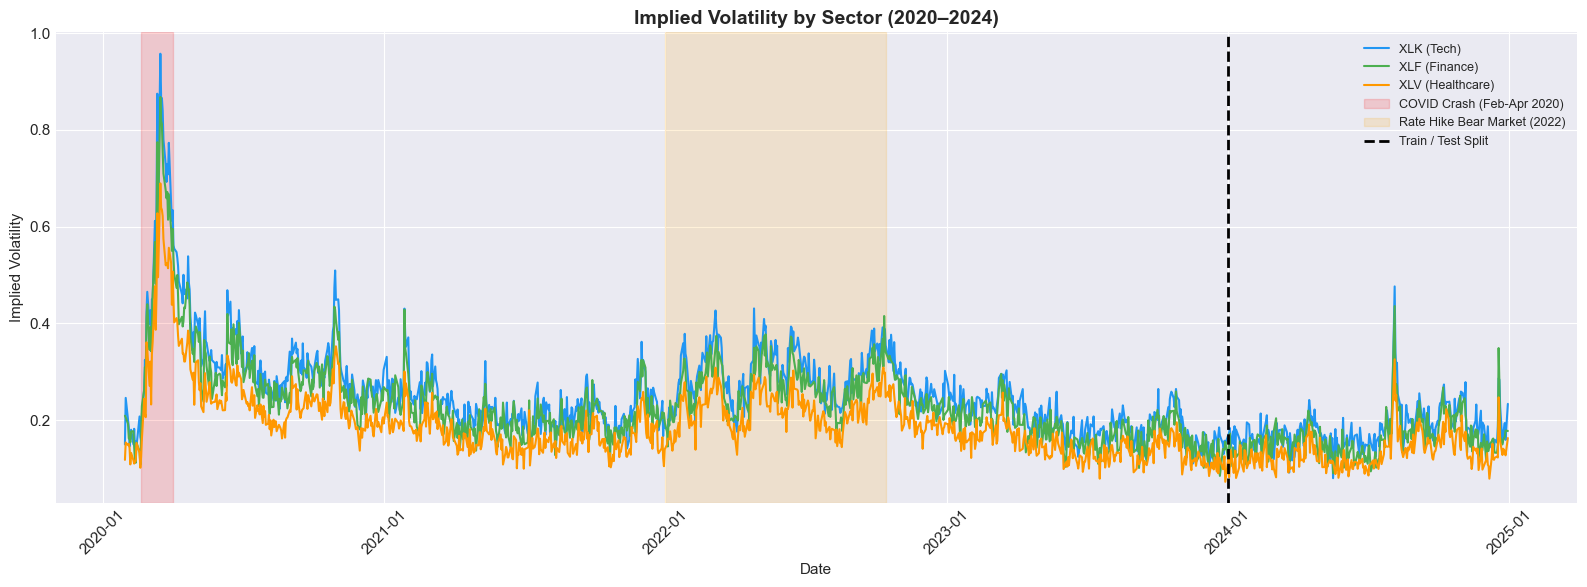

IV Summary Statistics:
          iv_xlk     iv_xlf     iv_xlv
count  1238.0000  1238.0000  1238.0000
mean      0.2485     0.2267     0.1832
std       0.0965     0.0892     0.0720
min       0.0800     0.0847     0.0726
25%       0.1845     0.1679     0.1347
50%       0.2296     0.2097     0.1713
75%       0.2868     0.2675     0.2145
max       0.9574     0.8681     0.6894

Peak IV dates:
  XLK: 0.957 on 2020-03-16
  XLF: 0.868 on 2020-03-16
  XLV: 0.689 on 2020-03-16


In [2]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df['date'], df['iv_xlk'], label='XLK (Tech)',        linewidth=1.5, color='#2196F3')
ax.plot(df['date'], df['iv_xlf'], label='XLF (Finance)',     linewidth=1.5, color='#4CAF50')
ax.plot(df['date'], df['iv_xlv'], label='XLV (Healthcare)',  linewidth=1.5, color='#FF9800')

# Mark known market stress events
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-01'),
           alpha=0.15, color='red',    label='COVID Crash (Feb-Apr 2020)')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-10-15'),
           alpha=0.15, color='orange', label='Rate Hike Bear Market (2022)')

# Train/test split line
ax.axvline(pd.Timestamp('2024-01-01'), color='black',
           linestyle='--', linewidth=2, label='Train / Test Split')

ax.set_title('Implied Volatility by Sector (2020–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Implied Volatility')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../notebooks/iv_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

# Key stats
print('IV Summary Statistics:')
print(df[['iv_xlk','iv_xlf','iv_xlv']].describe().round(4).to_string())
print(f"\nPeak IV dates:")
for col, label in [('iv_xlk','XLK'),('iv_xlf','XLF'),('iv_xlv','XLV')]:
    idx = df[col].idxmax()
    print(f"  {label}: {df[col].max():.3f} on {df.loc[idx,'date'].date()}")

## 2. Z-Score Distribution + Override Threshold Analysis

The Vasant Dhar override triggers when **ALL** sector z-scores exceed 2.5 simultaneously.
This should only happen during genuine market crises.

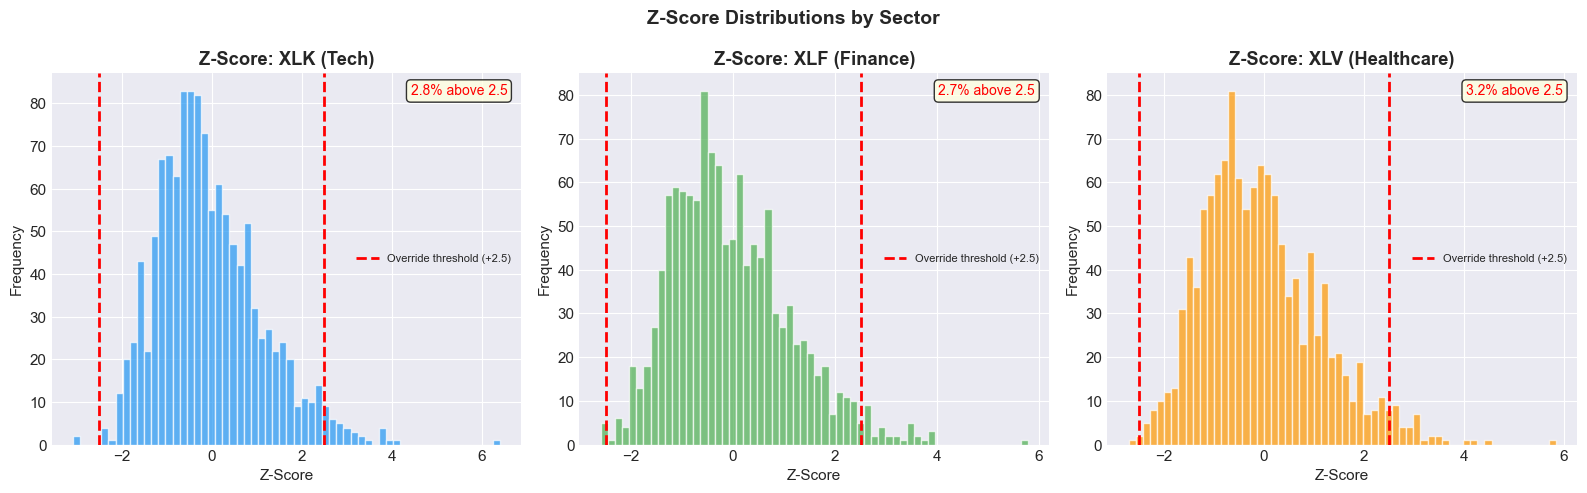

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

zscore_cols = ['zscore_xlk', 'zscore_xlf', 'zscore_xlv']
titles      = ['XLK (Tech)', 'XLF (Finance)', 'XLV (Healthcare)']
colors      = ['#2196F3',    '#4CAF50',        '#FF9800']

for ax, col, title, color in zip(axes, zscore_cols, titles, colors):
    data = df[col].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.7, edgecolor='white')
    ax.axvline( 2.5, color='red', linestyle='--', linewidth=2, label='Override threshold (+2.5)')
    ax.axvline(-2.5, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Z-Score: {title}', fontweight='bold')
    ax.set_xlabel('Z-Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

    pct = (data > 2.5).mean() * 100
    ax.text(0.97, 0.97, f'{pct:.1f}% above 2.5',
            transform=ax.transAxes, ha='right', va='top',
            color='red', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Z-Score Distributions by Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/zscore_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Override trigger analysis
override_mask = (df[zscore_cols] > 2.5).all(axis=1)
n_override    = override_mask.sum()

print(f'Override Trigger Analysis (threshold = 2.5 std devs)')
print(f'=' * 55)
print(f'Total override days : {n_override} / {len(df)} ({n_override/len(df)*100:.1f}%)')
print(f'Expected            : ~1-3% (only genuine crises)')
print()

if n_override > 0:
    override_df = df[override_mask][['date'] + zscore_cols].copy()
    override_df['date'] = override_df['date'].dt.strftime('%Y-%m-%d')
    print('Override dates (first 10):')
    print(override_df.head(10).to_string(index=False))
    print()
    print('These should align with the COVID crash (Feb-Mar 2020)')

Override Trigger Analysis (threshold = 2.5 std devs)
Total override days : 19 / 1238 (1.5%)
Expected            : ~1-3% (only genuine crises)

Override dates (first 10):
      date  zscore_xlk  zscore_xlf  zscore_xlv
2020-02-24    2.991634    2.984123    4.154652
2020-02-25    3.731895    3.433915    2.681244
2020-02-27    4.116894    3.890818    4.546300
2020-02-28    3.766573    3.542750    3.474938
2020-03-09    3.346218    3.235838    3.458938
2020-03-11    2.961854    2.793518    2.761460
2020-03-12    3.835879    3.644413    3.684099
2020-03-16    3.524146    3.456569    3.404695
2020-03-17    2.779002    2.877441    2.780056
2020-03-18    2.570371    2.620631    2.547634

These should align with the COVID crash (Feb-Mar 2020)


## 3. Z-Score Time Series — Visualising Override Periods

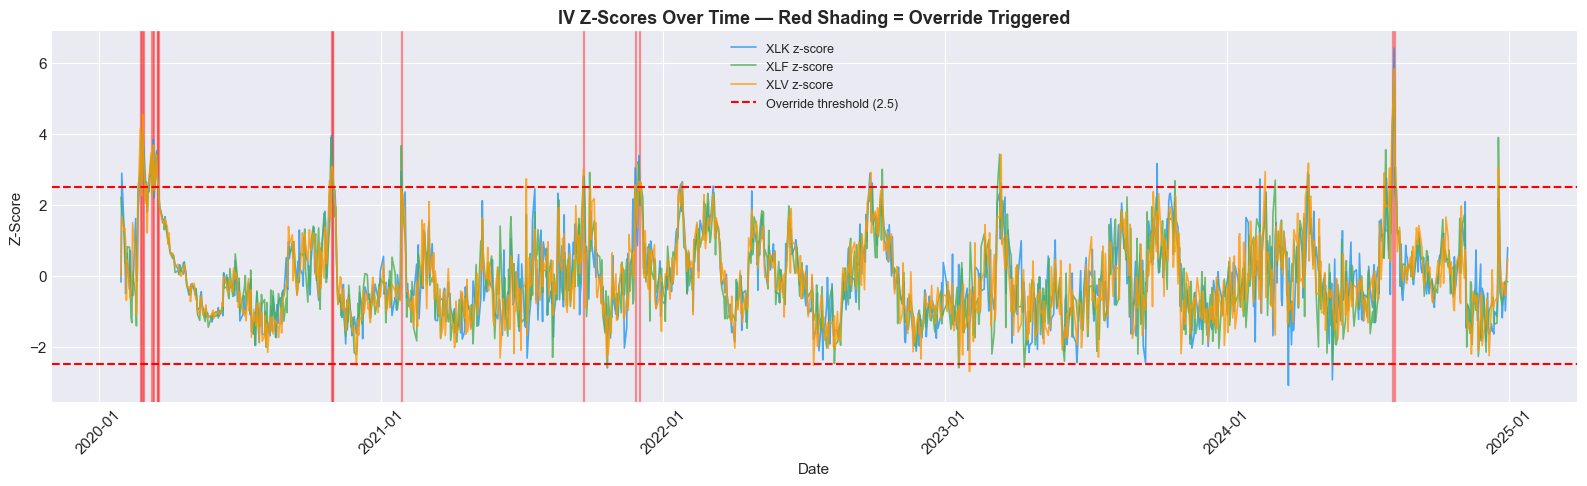

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['date'], df['zscore_xlk'], label='XLK z-score', linewidth=1.2, color='#2196F3', alpha=0.8)
ax.plot(df['date'], df['zscore_xlf'], label='XLF z-score', linewidth=1.2, color='#4CAF50', alpha=0.8)
ax.plot(df['date'], df['zscore_xlv'], label='XLV z-score', linewidth=1.2, color='#FF9800', alpha=0.8)

# Override threshold lines
ax.axhline( 2.5, color='red', linestyle='--', linewidth=1.5, label='Override threshold (2.5)')
ax.axhline(-2.5, color='red', linestyle='--', linewidth=1.5)

# Shade override periods
override_dates = df[override_mask]['date']
for d in override_dates:
    ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.3, color='red')

ax.set_title('IV Z-Scores Over Time — Red Shading = Override Triggered', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Z-Score')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../notebooks/zscore_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Realized Volatility vs Implied Volatility

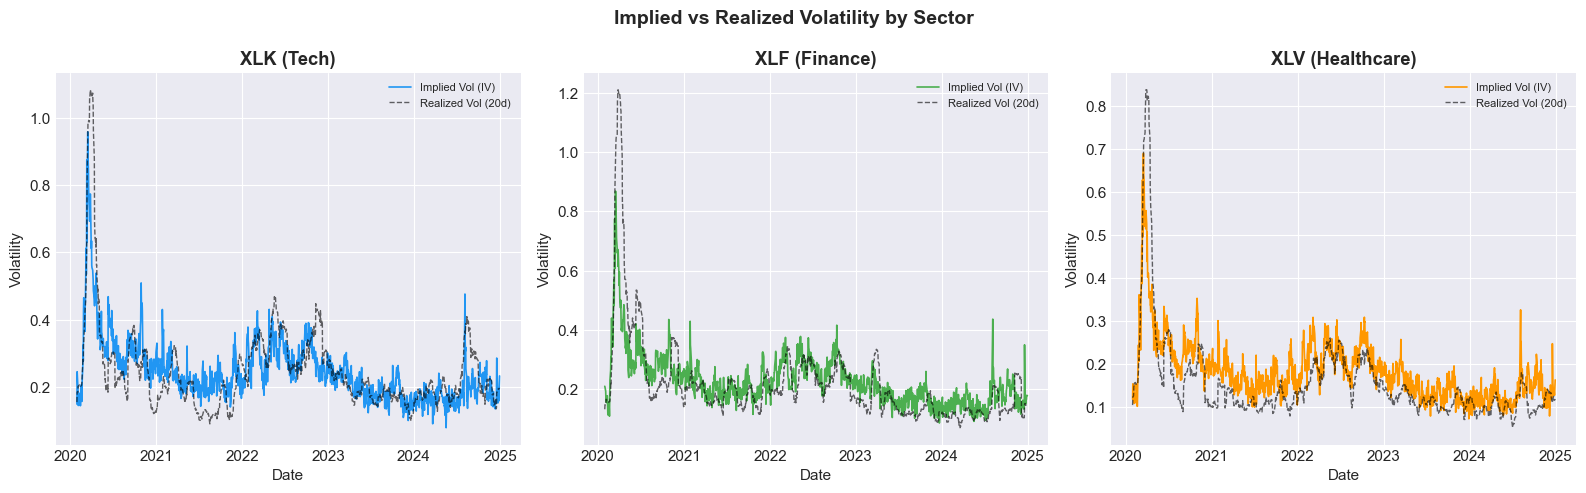

Volatility Risk Premium (IV - Realized Vol):
Positive = market pricing in more fear than actually occurred
  XLK (Tech)          : avg premium = -0.0011
  XLF (Finance)       : avg premium = 0.0094
  XLV (Healthcare)    : avg premium = 0.0286


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('iv_xlk', 'realvol_xlk', 'XLK (Tech)',        '#2196F3'),
    ('iv_xlf', 'realvol_xlf', 'XLF (Finance)',      '#4CAF50'),
    ('iv_xlv', 'realvol_xlv', 'XLV (Healthcare)',   '#FF9800'),
]

for ax, (iv_col, rv_col, title, color) in zip(axes, pairs):
    ax.plot(df['date'], df[iv_col], label='Implied Vol (IV)',   color=color,   linewidth=1.2)
    ax.plot(df['date'], df[rv_col], label='Realized Vol (20d)', color='black', linewidth=1.0, alpha=0.6, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Volatility')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Implied vs Realized Volatility by Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/iv_vs_realvol.png', dpi=150, bbox_inches='tight')
plt.show()

print('Volatility Risk Premium (IV - Realized Vol):')
print('Positive = market pricing in more fear than actually occurred')
for iv_col, rv_col, label, _ in pairs:
    premium = (df[iv_col] - df[rv_col]).mean()
    print(f'  {label:<20}: avg premium = {premium:.4f}')

## 5. SPY Buy-and-Hold Baseline

This is the benchmark our RL agent must beat.

In [7]:
# Compute metrics for all strategies
strategies = {
    'SPY':  df['ret_spy'].dropna().values,
    'XLK':  df['ret_xlk'].dropna().values,
    'XLF':  df['ret_xlf'].dropna().values,
    'XLV':  df['ret_xlv'].dropna().values,
}

print('=' * 65)
print(f'{"SECTOR PERFORMANCE (2020-2024 Full Period)":^65}')
print('=' * 65)
print(f'{"Strategy":<12} {"Sortino":>10} {"Sharpe":>10} {"Total%":>10} {"MaxDD%":>10}')
print('-' * 65)

for name, rets in strategies.items():
    print(f'{name:<12} '
          f'{sortino_ratio(rets):>10.3f} '
          f'{sharpe_ratio(rets):>10.3f} '
          f'{total_return(rets):>10.2f} '
          f'{max_drawdown(rets)*100:>10.2f}')

print('=' * 65)
print('\nOur RL agent needs to beat SPY Sortino on the 2024 test set!')

           SECTOR PERFORMANCE (2020-2024 Full Period)            
Strategy        Sortino     Sharpe     Total%     MaxDD%
-----------------------------------------------------------------
SPY               0.760      0.638      94.25     -33.72
XLK               0.883      0.670     152.46     -33.56
XLF               0.536      0.434      76.25     -42.86
XLV               0.537      0.416      45.84     -28.14

Our RL agent needs to beat SPY Sortino on the 2024 test set!


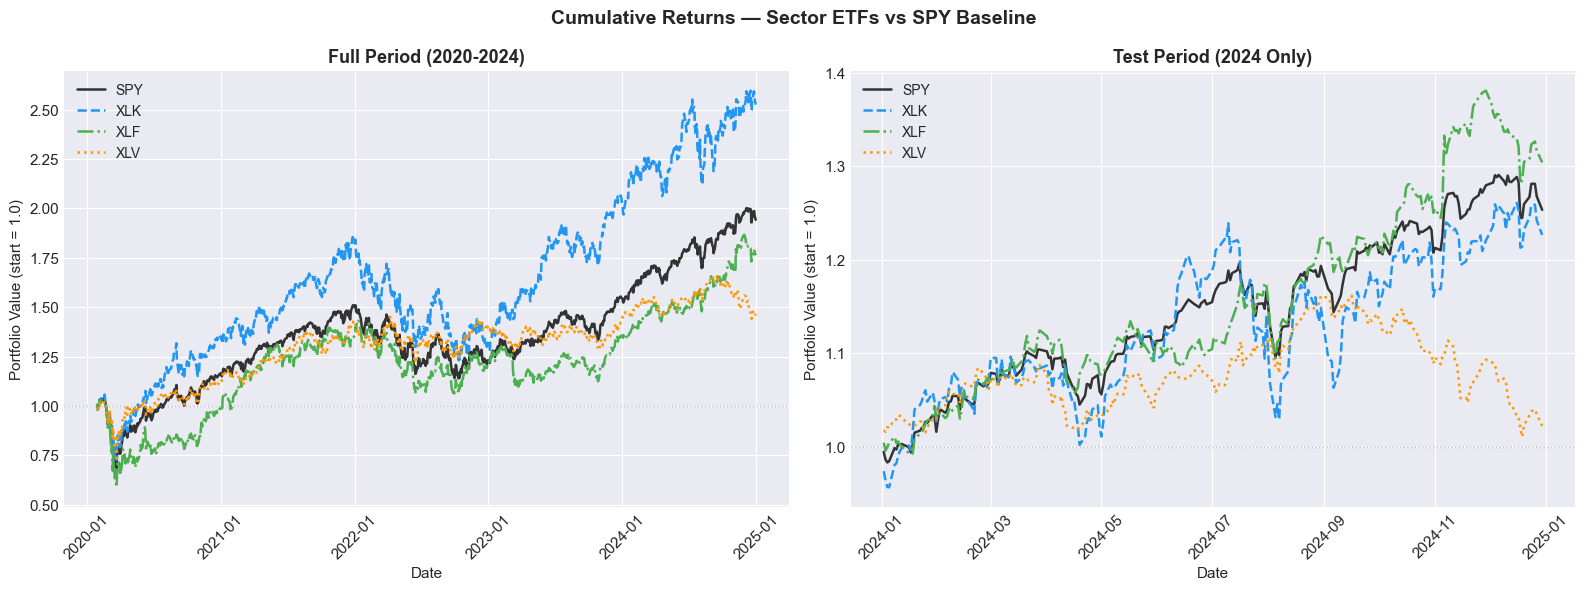

In [8]:
# Cumulative returns chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_map = {'SPY': '#333333', 'XLK': '#2196F3', 'XLF': '#4CAF50', 'XLV': '#FF9800'}
styles_map = {'SPY': '-',       'XLK': '--',       'XLF': '-.',      'XLV': ':'}

for ax, subset_df, title in [
    (axes[0], df,    'Full Period (2020-2024)'),
    (axes[1], test,  'Test Period (2024 Only)'),
]:
    for name, col in [('SPY','ret_spy'),('XLK','ret_xlk'),('XLF','ret_xlf'),('XLV','ret_xlv')]:
        rets = subset_df[col].dropna().values
        cum  = cumulative_returns(rets)
        dates = subset_df.dropna(subset=[col])['date'].values
        ax.plot(dates[-len(cum):], cum,
                label=name, color=colors_map[name],
                linestyle=styles_map[name], linewidth=1.8)

    ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Portfolio Value (start = 1.0)')
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Cumulative Returns — Sector ETFs vs SPY Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/cumulative_returns_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Return Distributions

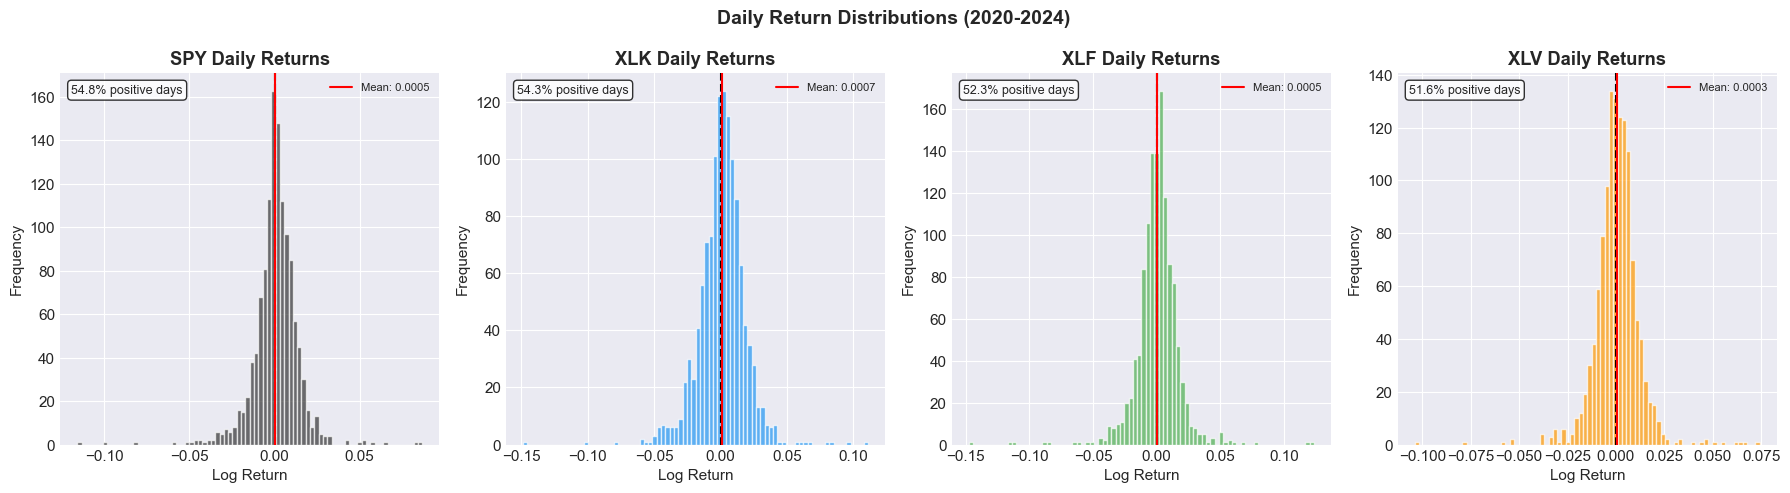

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (name, col, color) in zip(axes, [
    ('SPY',  'ret_spy',  '#333333'),
    ('XLK',  'ret_xlk',  '#2196F3'),
    ('XLF',  'ret_xlf',  '#4CAF50'),
    ('XLV',  'ret_xlv',  '#FF9800'),
]):
    rets = df[col].dropna()
    ax.hist(rets, bins=80, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(rets.mean(), color='red', linestyle='-', linewidth=1.5, label=f'Mean: {rets.mean():.4f}')
    ax.set_title(f'{name} Daily Returns', fontweight='bold')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    pct_positive = (rets > 0).mean() * 100
    ax.text(0.03, 0.97, f'{pct_positive:.1f}% positive days',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Daily Return Distributions (2020-2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlation Between Sectors

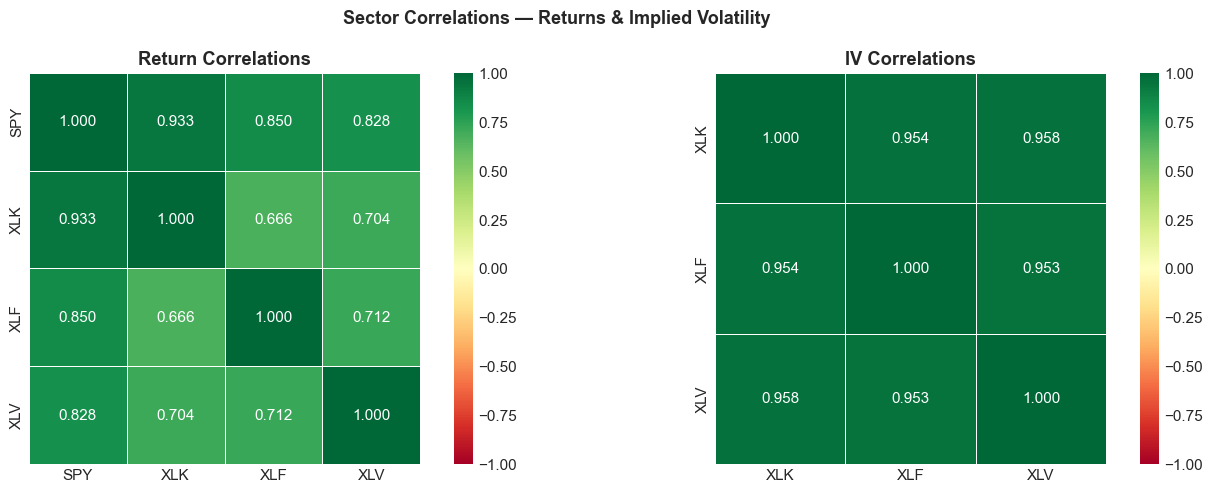

High IV correlation = sectors tend to be fearful together
This is why the override requires ALL sectors to spike, not just one


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return correlations
ret_corr = df[['ret_spy','ret_xlk','ret_xlf','ret_xlv']].corr()
ret_corr.columns = ['SPY','XLK','XLF','XLV']
ret_corr.index   = ['SPY','XLK','XLF','XLV']

sns.heatmap(ret_corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, square=True)
axes[0].set_title('Return Correlations', fontweight='bold')

# IV correlations
iv_corr = df[['iv_xlk','iv_xlf','iv_xlv']].corr()
iv_corr.columns = ['XLK','XLF','XLV']
iv_corr.index   = ['XLK','XLF','XLV']

sns.heatmap(iv_corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[1],
            linewidths=0.5, square=True)
axes[1].set_title('IV Correlations', fontweight='bold')

plt.suptitle('Sector Correlations — Returns & Implied Volatility', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('High IV correlation = sectors tend to be fearful together')
print('This is why the override requires ALL sectors to spike, not just one')

## 8. EDA Summary

Key findings for the report:

In [11]:
print('=' * 60)
print('EDA SUMMARY — KEY FINDINGS')
print('=' * 60)

print(f'\n1. DATASET')
print(f'   Total days : {len(df):,}')
print(f'   Train days : {len(train):,} (2020-2023)')
print(f'   Test days  : {len(test):,} (2024)')

print(f'\n2. IMPLIED VOLATILITY')
for col, name in [('iv_xlk','XLK'),('iv_xlf','XLF'),('iv_xlv','XLV')]:
    print(f'   {name}: mean={df[col].mean():.3f}, max={df[col].max():.3f}, std={df[col].std():.3f}')

print(f'\n3. OVERRIDE ANALYSIS')
print(f'   Trigger days : {n_override} ({n_override/len(df)*100:.1f}% of all days)')
print(f'   Key period   : COVID crash Feb-Mar 2020')
print(f'   Threshold    : 2.5 standard deviations across ALL sectors')

print(f'\n4. SPY BASELINE (full period 2020-2024)')
spy_rets = df['ret_spy'].dropna().values
print(f'   Sortino : {sortino_ratio(spy_rets):.4f}')
print(f'   Sharpe  : {sharpe_ratio(spy_rets):.4f}')
print(f'   Return  : {total_return(spy_rets):.2f}%')
print(f'   Max DD  : {max_drawdown(spy_rets)*100:.2f}%')

print(f'\n5. AGENT TARGET (2024 test set)')
spy_2024 = test['ret_spy'].dropna().values
print(f'   SPY 2024 Sortino : {sortino_ratio(spy_2024):.4f}')
print(f'   SPY 2024 Return  : {total_return(spy_2024):.2f}%')
print(f'   → Our agent must beat these on the 2024 test set')

print('=' * 60)

EDA SUMMARY — KEY FINDINGS

1. DATASET
   Total days : 1,238
   Train days : 987 (2020-2023)
   Test days  : 251 (2024)

2. IMPLIED VOLATILITY
   XLK: mean=0.248, max=0.957, std=0.096
   XLF: mean=0.227, max=0.868, std=0.089
   XLV: mean=0.183, max=0.689, std=0.072

3. OVERRIDE ANALYSIS
   Trigger days : 19 (1.5% of all days)
   Key period   : COVID crash Feb-Mar 2020
   Threshold    : 2.5 standard deviations across ALL sectors

4. SPY BASELINE (full period 2020-2024)
   Sortino : 0.7602
   Sharpe  : 0.6375
   Return  : 94.25%
   Max DD  : -33.72%

5. AGENT TARGET (2024 test set)
   SPY 2024 Sortino : 2.3420
   SPY 2024 Return  : 25.34%
   → Our agent must beat these on the 2024 test set
